# SAMOS2026 Core3CS Project
### Group ASAYIKO
**Visualizing Remote-Sensed Ocean Colour Data**

Contributors: Koketso, Asanda, Yibanathi  
Date: May 2026



## Introduction
This project combines multiple methods to analyze and visualize oceanographic data. 
We use ESA-CCI Ocean Colour climatology to study chlorophyll concentration, alongside bathymetry data to understand physical drivers of phytoplankton distribution. 
By integrating maps, time series, and metadata analysis, we aim to highlight seasonal cycles and spatial variability in coastal regions.



In [13]:
import xarray as xr

chl = xr.open_dataset("ESACCI-OC-MAPPED-CLIMATOLOGY-1M_MONTHLY_4km_PML_CHL-fv5.0.nc")
chl.info()



xarray.Dataset {
dimensions:
	time = 12 ;
	lat = 4320 ;
	lon = 8640 ;

variables:
	int32 crs() ;
		crs:grid_mapping_name = latitude_longitude ;
	float32 chlor_a(time, lat, lon) ;
		chlor_a:standard_name = mass_concentration_of_chlorophyll_a_in_sea_water ;
		chlor_a:long_name = Chlorophyll-a concentration in seawater (not log-transformed), generated by as a blended combination of OCI, OCI2, OC2 and OCx algorithms, depending on water class memberships ;
		chlor_a:units = milligram m-3 ;
		chlor_a:grid_mapping = crs ;
		chlor_a:ancillary_variables = chlor_a_log10_rmsd chlor_a_log10_bias ;
		chlor_a:parameter_vocab_uri = http://vocab.ndg.nerc.ac.uk/term/P011/current/CHLTVOLU ;
		chlor_a:units_nonstandard = mg m^-3 ;
	datetime64[ns] time(time) ;
		time:standard_name = time ;
		time:axis = T ;
	float64 lon(lon) ;
		lon:standard_name = longitude ;
		lon:long_name = longitude ;
		lon:units = degrees_east ;
		lon:axis = X ;
	float64 lat(lat) ;
		lat:standard_name = latitude ;
		lat:long_name = 

In [14]:
import os
print(os.listdir("."))


['Exercise5.ipynb', 'ESACCI-OC-MAPPED-CLIMATOLOGY-1M_MONTHLY_4km_PML_CHL-fv5.0.nc', '.ipynb_checkpoints']


## Time Series Analysis of Chlorophyll-a

To examine the seasonal variability of chlorophyll-a in St Helena Bay, we extract a 
regional subset of the ESA-CCI climatology bounded by 33.5°S–32.0°S and 17.5°E–19.0°E. 
The regional mean is computed by averaging all valid ocean pixels across this domain for 
each month, while a single grid point at 32.6°S, 17.7°E is selected to represent local 
variability. Both time series are plotted to compare the broader seasonal signal with 
point-scale dynamics. St Helena Bay is part of the Benguela Current upwelling system, 
where strong seasonal winds drive nutrient-rich cold water to the surface, fuelling 
elevated phytoplankton biomass — reflected here by peak chlorophyll concentrations in 
March–April and a summer minimum in July–August.

In [24]:
# Check lat direction
print("Lat min:", float(chl.lat.min()), "Lat max:", float(chl.lat.max()))
print("First few lat values:", chl.lat.values[:5])

# Check what the region actually contains
lat_min, lat_max = -33.5, -32.0
lon_min, lon_max = 17.5, 19.0

chl_region = chl['chlor_a'].sel(lat=slice(lat_max, lat_min), lon=slice(lon_min, lon_max))
print("Region shape:", chl_region.shape)
print("Non-NaN count:", int((~np.isnan(chl_region)).sum()))
print("Sample values:", chl_region.isel(time=0).values)

Lat min: -89.97916666666666 Lat max: 89.97916666666667
First few lat values: [89.97916667 89.9375     89.89583333 89.85416667 89.8125    ]
Region shape: (12, 36, 36)
Non-NaN count: 7368
Sample values: [[3.1443236 3.1443236 3.1738677 ...       nan       nan       nan]
 [3.164599  3.2525642 3.3181834 ...       nan       nan       nan]
 [3.3930354 3.387668  3.4434998 ...       nan       nan       nan]
 ...
 [2.282749  2.5949156 2.859337  ...       nan       nan       nan]
 [2.1002805 2.4757617 2.8258264 ...       nan       nan       nan]
 [2.1697457 2.5053596 2.5053596 ...       nan       nan       nan]]


Selected grid point: -32.65°S, 17.73°E
Regional mean values: [4.46  4.647 5.144 4.94  3.916 2.635 2.222 2.324 2.747 3.245 3.555 3.81 ]
Single point values:  [3.616 4.233 4.518 4.709 3.542 2.084 1.56  1.73  2.037 2.711 3.412 3.34 ]


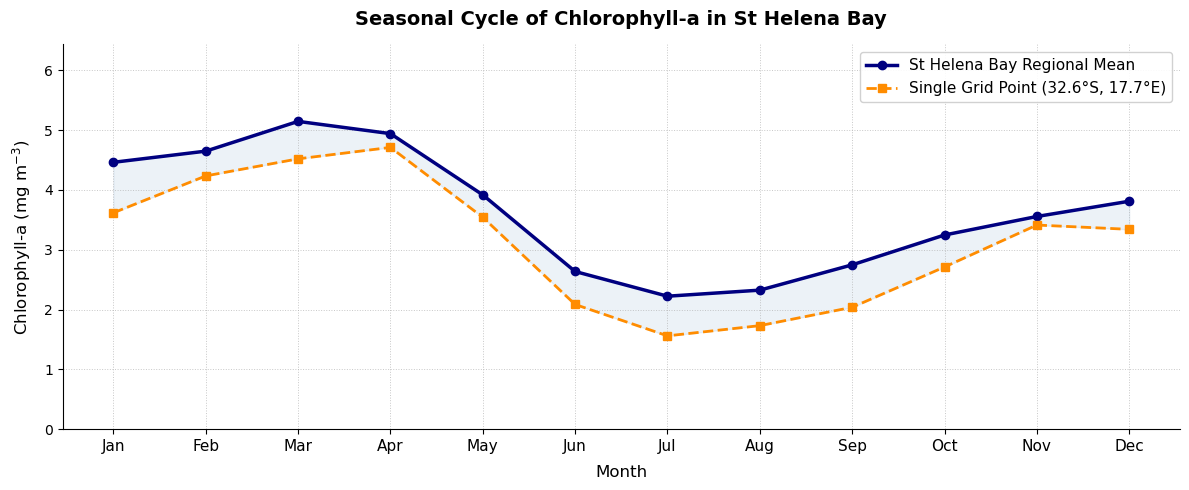

In [26]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

# ── 1. Load dataset ──────────────────────────────────────────────────────────
chl = xr.open_dataset("ESACCI-OC-MAPPED-CLIMATOLOGY-1M_MONTHLY_4km_PML_CHL-fv5.0.nc")

# ── 2. Define region (St Helena Bay) ─────────────────────────────────────────
lat_min, lat_max = -33.5, -32.0
lon_min, lon_max = 17.5, 19.0

# lat_max first because dataset latitude runs descending (90 → -90)
chl_region = chl['chlor_a'].sel(
    lat=slice(lat_max, lat_min),
    lon=slice(lon_min, lon_max)
)

# ── 3. Regional mean (ignores land/NaN pixels) ────────────────────────────────
chl_mean = chl_region.mean(dim=["lat", "lon"], skipna=True)

# ── 4. Find a valid single grid point inside the bay ─────────────────────────
# Scan the region at time=0 to find the first non-NaN ocean pixel
sample = chl['chlor_a'].isel(time=0).sel(
    lat=slice(lat_max, lat_min),
    lon=slice(lon_min, lon_max)
)
valid = np.argwhere(~np.isnan(sample.values))

if len(valid) == 0:
    raise ValueError("No valid ocean pixels found in region — check bounds")

# Pick a point roughly in the middle of valid pixels (more representative)
mid = valid[len(valid) // 2]
point_lat = float(sample.lat[mid[0]])
point_lon = float(sample.lon[mid[1]])
print(f"Selected grid point: {point_lat:.2f}°S, {point_lon:.2f}°E")

chl_point = chl['chlor_a'].sel(lat=point_lat, lon=point_lon, method="nearest")

# ── 5. Confirm values look sensible ──────────────────────────────────────────
print("Regional mean values:", np.round(chl_mean.values, 3))
print("Single point values: ", np.round(chl_point.values, 3))

# ── 6. Plot ───────────────────────────────────────────────────────────────────
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
x = np.arange(1, 13)

mean_vals  = chl_mean.values
point_vals = chl_point.values

fig, ax = plt.subplots(figsize=(12, 5))

# Regional mean line
ax.plot(x, mean_vals,
        color='navy', linewidth=2.5,
        marker='o', markersize=6,
        label='St Helena Bay Regional Mean')

# Single grid point line
ax.plot(x, point_vals,
        color='darkorange', linewidth=2,
        linestyle='--', marker='s', markersize=6,
        label=f'Single Grid Point ({abs(point_lat):.1f}°S, {point_lon:.1f}°E)')

# Shaded band between the two lines
ax.fill_between(x, mean_vals, point_vals,
                alpha=0.10, color='steelblue')

# ── Axes formatting ───────────────────────────────────────────────────────────
ax.set_xticks(x)
ax.set_xticklabels(months, fontsize=11)
ax.set_xlabel("Month", fontsize=12, labelpad=8)
ax.set_ylabel("Chlorophyll-a (mg m$^{-3}$)", fontsize=12, labelpad=8)
ax.set_title("Seasonal Cycle of Chlorophyll-a in St Helena Bay",
             fontsize=14, fontweight='bold', pad=14)

# Safe y-axis upper limit
all_vals = np.concatenate([mean_vals, point_vals])
ymax = np.nanmax(all_vals) * 1.25
ymax = ymax if np.isfinite(ymax) else 8.0   # fallback
ax.set_ylim(0, ymax)

ax.legend(fontsize=11, framealpha=0.9, loc='upper right')
ax.grid(True, linestyle=':', linewidth=0.7, alpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("chl_timeseries_StHelenaBay.png", dpi=300, bbox_inches='tight')
plt.show()

**Figure 3:** Seasonal cycle of chlorophyll-a concentration (mg m⁻³) in St Helena Bay 
(17.5°–19.0°E, 33.5°–32.0°S) derived from ESA-CCI Ocean Colour climatology (1998–2020). 
The navy line shows the spatial mean over the region; the orange dashed line represents 
a single grid point at 32.6°S, 17.7°E. The shaded area highlights the difference between 
regional and local variability. Peak concentrations in March–April reflect enhanced 
phytoplankton growth associated with Benguela upwelling.